--- VÝSLEDKY MODELU (SPARTA) ---
Průměrná chyba (MAE): 1784 diváků
Spolehlivost (R2): 0.63


C:\Users\bkolm\AppData\Local\Temp\ipykernel_53804\3704172705.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vliv (%)', y='Kategorie', data=importance_df, ax=ax2, palette='Reds_r')


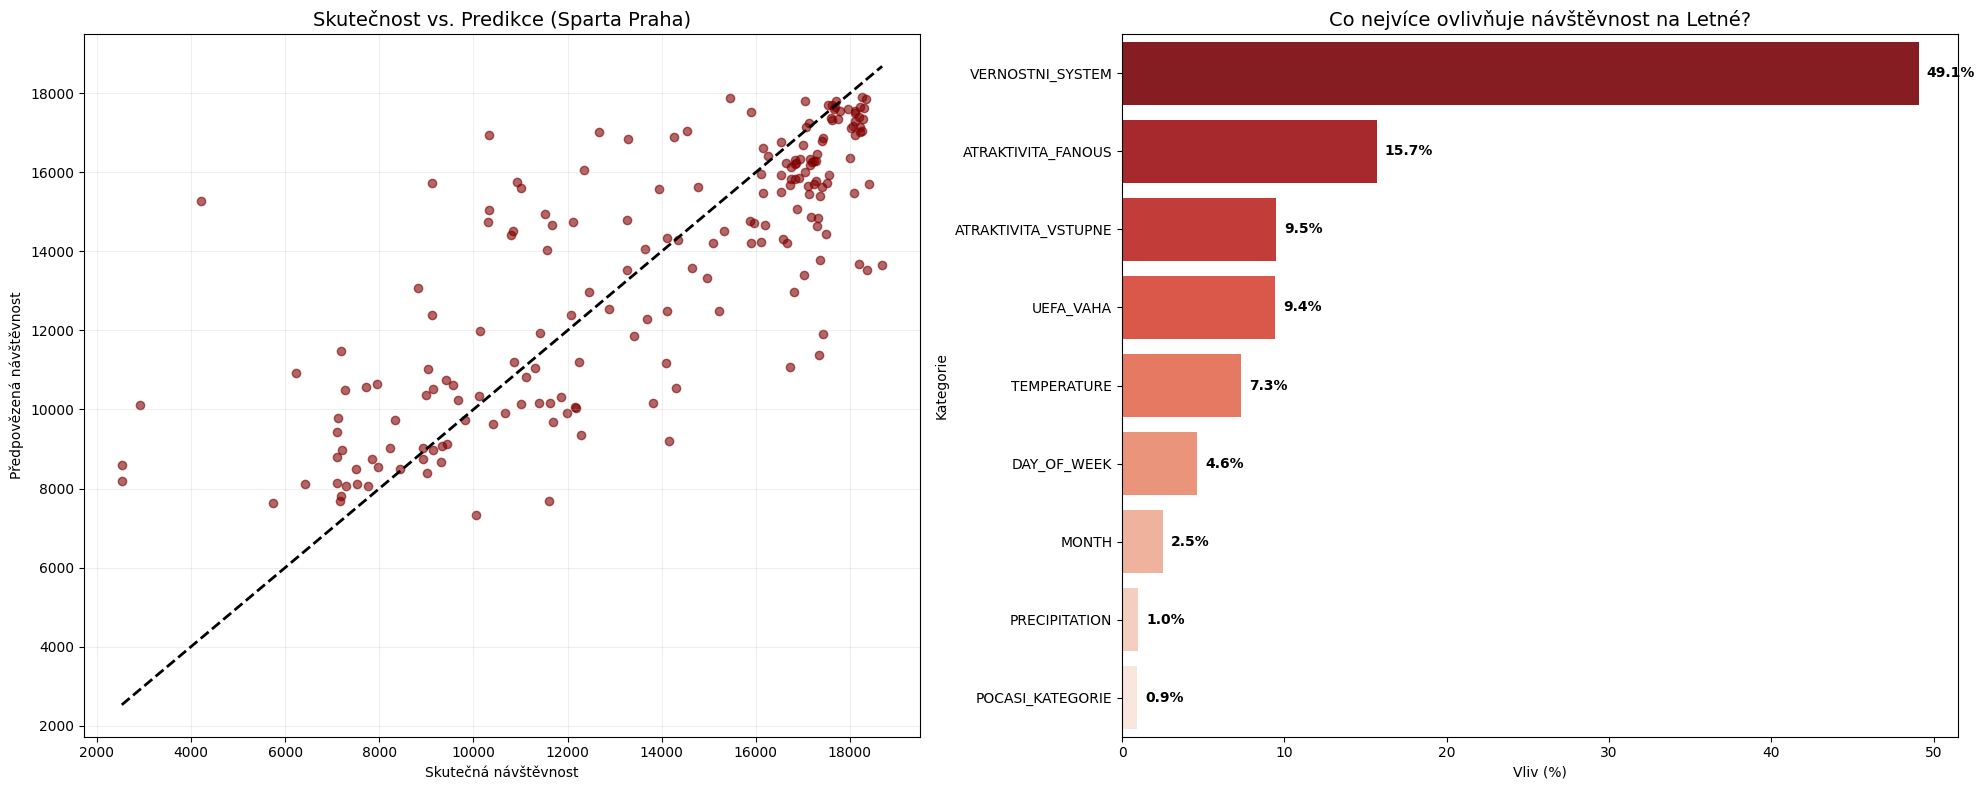

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

# 1. NAČTENÍ SOUBORU
# Načítáme Spartu - pozor na oddělovač (v CSV bývá čárka nebo středník)
df = pd.read_csv('SPARTA_FINAL1.csv')


# 3. VÝBĚR KATEGORIÍ (FEATURES)
features = [
    'VERNOSTNI_SYSTEM',
    'POCASI_KATEGORIE',    
    'TEMPERATURE',         
    'ATRAKTIVITA_FANOUS',  
    'ATRAKTIVITA_VSTUPNE', 
    'PRECIPITATION',       
    'DAY_OF_WEEK',           
    'MONTH',               
    'UEFA_VAHA'            
]
target = 'ATTENDANCE'

# Vyčištění dat
df_model = df.dropna(subset=[target]).copy()

X = df_model[features]
y = df_model[target]

# 4. KONSTRUKCE MODELU
model_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), 
    ("model", RandomForestRegressor(
        n_estimators=500,
        max_depth=7,           
        min_samples_leaf=5,
        random_state=42
    ))
])

# 5. TESTOVÁNÍ (K-Fold Cross-Validation)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(model_pipeline, X, y, cv=cv)

# Statistiky
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"--- VÝSLEDKY MODELU (SPARTA) ---")
print(f"Průměrná chyba (MAE): {mae:.0f} diváků")
print(f"Spolehlivost (R2): {r2:.2f}")

# 6. ANALÝZA VLIVU KATEGORIÍ
model_pipeline.fit(X, y)
importances = model_pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({
    'Kategorie': features, 
    'Vliv (%)': importances * 100
}).sort_values('Vliv (%)', ascending=False)

# 7. VIZUALIZACE VÝSLEDKŮ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Graf A: Porovnání reality a předpovědi
ax1.scatter(y, y_pred, alpha=0.6, color="#005180") # Sparťanská rudá
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
ax1.set_title('Skutečnost vs. Predikce (Sparta Praha)', fontsize=14)
ax1.set_xlabel('Skutečná návštěvnost')
ax1.set_ylabel('Předpovězená návštěvnost')
ax1.grid(True, alpha=0.2)

# Graf B: Důležitost faktorů
sns.barplot(x='Vliv (%)', y='Kategorie', data=importance_df, ax=ax2, palette='Reds_r')
ax2.set_title('Co nejvíce ovlivňuje návštěvnost na Letné?', fontsize=14)
for i, v in enumerate(importance_df['Vliv (%)']):
    ax2.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
importance_df


In [4]:
export_df = pd.DataFrame({
    'Datum': df_model['DATE'].values,
    'Soupeř': df_model['AWAYTEAM'].values,
    'Skutečná návštěvnost': y.values.astype(int),
    'Predikovaná návštěvnost': y_pred.astype(int),
    'Rozdíl (chyba)': y.values.astype(int) - y_pred.astype(int)
})

export_df.to_csv('predikce_navstevnosti.csv', index=False, encoding='utf-8-sig', sep=';')

print("Hotovo! Soubor 'predikce_navstevnosti.csv' byl vytvořen.")

Hotovo! Soubor 'predikce_navstevnosti.csv' byl vytvořen.


In [7]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime, date
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# 1. FUNKCE PRO ZÍSKÁNÍ POČASÍ
def get_weather_data(date_str, time_str):
    lat, lon = 50.08787, 14.475525
    try:
        if len(time_str) <= 2: time_str += ":00"
        target_dt = datetime.strptime(f"{date_str} {time_str}", "%Y-%m-%d %H:%M")
    except ValueError:
        print("⚠️ Špatný formát data nebo času.")
        return None
        
    today = date.today()
    url = "https://archive-api.open-meteo.com/v1/archive" if target_dt.date() < today else "https://api.open-meteo.com/v1/forecast"
        
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": date_str,
        "end_date": date_str,
        "hourly": ["temperature_2m", "precipitation", "rain", "snowfall"],
        "timezone": "Europe/Prague"
    }
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()
        hour = target_dt.hour
        return {
            'temp': data['hourly']['temperature_2m'][hour],
            'precip': data['hourly']['precipitation'][hour],
            'rain': data['hourly']['rain'][hour],
            'snow': data['hourly']['snowfall'][hour],
            'day_of_week': target_dt.weekday()  # VRACÍ 0-6 (Pondělí-Neděle)
        }
    except Exception as e:
        print(f"⚠️ Nepodařilo se načíst počasí: {e}")
        return None

# 2. TRÉNOVÁNÍ MODELU
def train_model():
    df = pd.read_csv("SPARTA_FINAL.csv")
    
    features = [
        'VERNOSTNI_SYSTEM', 'TEMPERATURE', 'ATRAKTIVITA_FANOUS', 'POCASI_KATEGORIE',
        'ATRAKTIVITA_VSTUPNE', 'PRECIPITATION', 'RAIN', 'SNOWFALL', 'DAY_OF_WEEK', 'UEFA_VAHA'
    ]
    target = 'ATTENDANCE'

    df = df.dropna(subset=[target])
    X = df[features]
    y = df[target]

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)

    model = RandomForestRegressor(n_estimators=500,
        max_depth=7,           
        min_samples_leaf=5,
        random_state=42)
    model.fit(X_imputed, y)
    
    return model, imputer, features

# 3. INTERAKTIVNÍ PREDIKCE
if __name__ == "__main__":
    model, imputer, feature_names = train_model()
    
    print("\n" + "="*55)
    print("      PREDIKCE NÁVŠTĚVNOSTI - SPARTA")
    print("="*55)
    
    datum = input("Zadej datum zápasu (RRRR-MM-DD): ")
    cas = input("Zadej čas výkopu (HH:00): ")
    souper = input("Zadej jméno soupeře: ")
    typ_zapasu = input("Je to UEFA zápas? (ano/ne): ").lower()

    top_list = ['slavia', 'plzen', 'plzeň', 'baník', 'banik']
    is_top = 1 if any(t in souper.lower() for t in top_list) else 0
    u_vaha = 1.0 if typ_zapasu == "ano" else 0.0
    
    weather = get_weather_data(datum, cas)

    if weather is None:
        print(f"\n❌ CHYBA: Nepodařilo se získat data o počasí.")
    else:
        # Vytvoření DataFrame se všemi sloupci 
        input_row = pd.DataFrame([{
            'VERNOSTNI_SYSTEM': 1,
            'TEMPERATURE': weather['temp'],
            'ATRAKTIVITA_FANOUS': 1.0 if is_top else 2.0,
            'ATRAKTIVITA_VSTUPNE': 1.0 if is_top else 3.0,
            'PRECIPITATION': weather['precip'],
            'RAIN': weather['rain'],
            'SNOWFALL': weather['snow'],
            'DAY_OF_WEEK': weather['day_of_week'], 
            'UEFA_VAHA': u_vaha,
            'POCASI_KATEGORIE': np.nan  # Imputer automaticky nahradí mediánem z historie
        }])

        # Seřazení sloupců přesně podle feature_names a transformace imputerem
        X_input = imputer.transform(input_row[feature_names])
        prediction = model.predict(X_input)[0]

        print("\n" + "*"*55)
        print(f"ZÁPAS:          Sparta Praha vs. {souper}")
        print(f"POČASÍ (API):   {weather['temp']}°C | Srážky: {weather['precip']}mm")
        print("-" * 55)
        print(f"ODHAD NÁVŠTĚVNOSTI: {int(round(prediction))} diváků")
        print("*"*55 + "\n")


      PREDIKCE NÁVŠTĚVNOSTI - SPARTA
⚠️ Špatný formát data nebo času.

❌ CHYBA: Nepodařilo se získat data o počasí.


In [2]:
import pandas as pd
import numpy as np
import requests
import unicodedata
from datetime import datetime, date
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# 1. POMOCNÁ FUNKCIA NA NORMALIZÁCIU TEXTU (rieši Zlin vs Zlín vs zlin)
def normalize_string(s):
    if not isinstance(s, str): return ""
    # Odstránenie diakritiky (mäkčeňov a dĺžňov)
    s = "".join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    # Malé písmená a odstránenie prebytočných medzier
    return s.lower().strip()

# 2. FUNKCIA PRE ZÍSKANIE POČASIA Z API
def get_weather_data(date_str, time_str):
    lat, lon = 50.08787, 14.475525
    try:
        if len(time_str) <= 2: time_str += ":00"
        target_dt = datetime.strptime(f"{date_str} {time_str}", "%Y-%m-%d %H:%M")
    except ValueError:
        print("⚠️ Chybný formát dátumu alebo času.")
        return None
        
    today = date.today()
    # Výber medzi archívom a predpoveďou
    url = "https://archive-api.open-meteo.com/v1/archive" if target_dt.date() < today else "https://api.open-meteo.com/v1/forecast"
        
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": date_str, "end_date": date_str,
        "hourly": ["temperature_2m", "precipitation", "rain", "snowfall"],
        "timezone": "Europe/Prague"
    }
    
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()
        hour = target_dt.hour
        return {
            'temp': data['hourly']['temperature_2m'][hour],
            'precip': data['hourly']['precipitation'][hour],
            'rain': data['hourly']['rain'][hour],
            'snow': data['hourly']['snowfall'][hour],
            'day_of_week': target_dt.weekday(),
            'month': target_dt.month
        }
    except Exception as e:
        print(f"⚠️ Nepodarilo sa načítať počasie: {e}")
        return None

# 3. TRÉNOVANIE MODELU
def train_model():
    # Načítanie dát Sparty
    df = pd.read_csv("SPARTA_FINAL.csv")
    
    # Príprava normalizovaného mena súpera pre Historický ťah
    df['AWAYTEAM_NORM'] = df['AWAYTEAM'].apply(normalize_string)
    
    # Výpočet historického ťahu (Target Encoding)
    tah_mapa = df.groupby('AWAYTEAM_NORM')['ATTENDANCE'].mean().to_dict()
    celkovy_prumer = df['ATTENDANCE'].mean()
    
    df['TAH_SOUPERE'] = df['AWAYTEAM_NORM'].map(tah_mapa)
    
    # Definícia faktorov (Features)
    features = [
        'TAH_SOUPERE', 'VERNOSTNI_SYSTEM', 'TEMPERATURE', 'ATRAKTIVITA_FANOUS', 
        'ATRAKTIVITA_VSTUPNE', 'PRECIPITATION', 'DAY_OF_WEEK', 'MONTH', 'UEFA_VAHA'
    ]
    target = 'ATTENDANCE'

    # Vyčistenie a trénovanie
    df = df.dropna(subset=[target])
    X = df[features]
    y = df[target]

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)

    # Model náhodného lesa
    model = RandomForestRegressor(n_estimators=1000, max_depth=10, min_samples_leaf=4, random_state=42)
    model.fit(X_imputed, y)
    
    return model, imputer, features, tah_mapa, celkovy_prumer

# 4. HLAVNÝ INTERAKTÍVNY PROGRAM
if __name__ == "__main__":
    model, imputer, feature_names, tah_mapa, celkovy_prumer = train_model()
    
    print("\n" + "="*60)
    print("      PREDIKCIA NÁVŠTEVNOSTI - AC SPARTA PRAHA")
    print("="*60)
    
    datum_vstup = input("Zadaj dátum zápasu (RRRR-MM-DD): ")
    cas_vstup = input("Zadaj čas výkopu (HH:00): ")
    souper_vstup = input("Zadaj meno súpera: ")
    typ_zapasu = input("Ide o UEFA zápas? (ano/nie): ").lower()

    # Spracovanie súpera (normalizácia)
    souper_norm = normalize_string(souper_vstup)
    historicky_tah = tah_mapa.get(souper_norm, celkovy_prumer)

    # Automatické nastavenie atraktivity pre top tímy
    top_list = ['slavia', 'plzen', 'banik']
    is_top = any(t in souper_norm for t in top_list)
    
    u_vaha = 1.0 if typ_zapasu == "ano" else 0.0
    
    # Získanie počasia
    weather = get_weather_data(datum_vstup, cas_vstup)

    if weather is None:
        print("\n❌ CHYBA: Model nemôže pracovať bez údajov o počasí.")
    else:
        # Príprava riadku pre predikciu
        input_data = pd.DataFrame([{
            'TAH_SOUPERE': historicky_tah,
            'VERNOSTNI_SYSTEM': 1, # Predpokladáme aktívny systém
            'TEMPERATURE': weather['temp'],
            'ATRAKTIVITA_FANOUS': 1.0 if is_top else 2.0,
            'ATRAKTIVITA_VSTUPNE': 1.0 if is_top else 3.0,
            'PRECIPITATION': weather['precip'],
            'DAY_OF_WEEK': weather['day_of_week'],
            'MONTH': weather['month'],
            'UEFA_VAHA': u_vaha
        }])

        # Zarovnanie stĺpcov podľa trénovaného modelu
        X_input = imputer.transform(input_data[feature_names])
        prediction = model.predict(X_input)[0]

        # VÝSLEDOK
        print("\n" + "*"*60)
        print(f"ZÁPAS:          Sparta Praha vs. {souper_vstup}")
        print(f"IDENTIFIKÁCIA:  {'Rozpoznaný historický súper' if souper_norm in tah_mapa else 'Nový súper (použitý priemer)'}")
        print(f"POČASIE:        {weather['temp']}°C | Srážky: {weather['precip']}mm")
        print("-" * 60)
        print(f"PREDPOKLADANÁ NÁVŠTEVNOSŤ: {int(round(prediction))} divákov")
        print("*"*60 + "\n")


      PREDIKCIA NÁVŠTEVNOSTI - AC SPARTA PRAHA

************************************************************
ZÁPAS:          Sparta Praha vs. Slavia
IDENTIFIKÁCIA:  Nový súper (použitý priemer)
POČASIE:        15.6°C | Srážky: 0.0mm
------------------------------------------------------------
PREDPOKLADANÁ NÁVŠTEVNOSŤ: 15923 divákov
************************************************************

